<a href="https://colab.research.google.com/github/leenmahmoud201/AI-Phase-One/blob/main/phaseone_group_14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project: Fetal Health Classification & Body Fat Regression

## Final Project: AI Classification & Regression
**Course:** CS362 - Artificial Intelligence  
**Phase:** Phase One

### Team Members:
* **Name:** Leen Mahmoud
* **Student ID:** 165930

In [72]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##Step 0: Imports and Reading Data

In [73]:
#import_Library
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
plt.style.use('ggplot')
pd.set_option('display.max_columns', None)
#Path
path_fetal = '/content/drive/MyDrive/Fetal Health Classification/fetal_health.csv'
path_bodyfat = '/content/drive/MyDrive/Body Fat Prediction Dataset/bodyfat.csv'
#Read_Data
df_fetal = pd.read_csv(path_fetal)
df_bodyfat = pd.read_csv(path_bodyfat)

##Step 1: Data Understanding

:# 1. Fetal Health Analysis (Classification)

Fetal Health Summary Statistics:
(2126, 22)


,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,mean_value_of_long_term_variability,histogram_width,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,10.4,130.0,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,13.4,130.0,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,23.0,117.0,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0


baseline value                                            float64
accelerations                                             float64
fetal_movement                                            float64
uterine_contractions                                      float64
light_decelerations                                       float64
severe_decelerations                                      float64
prolongued_decelerations                                  float64
abnormal_short_term_variability                           float64
mean_value_of_short_term_variability                      float64
percentage_of_time_with_abnormal_long_term_variability    float64
mean_value_of_long_term_variability                       float64
histogram_width                                           float64
histogram_min                                             float64
histogram_max                                             float64
histogram_number_of_peaks                                 float64
histogram_

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,mean_value_of_long_term_variability,histogram_width,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
count,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.00000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000
mean,133.303857,0.003178,0.009481,0.004366,0.001889,0.000003,0.000159,46.990122,1.332785,9.84666,8.187629,70.445908,93.579492,164.025400,4.068203,0.323612,137.452023,134.610536,138.090310,18.808090,0.320320,1.304327
std,9.840844,0.003866,0.046666,0.002946,0.002960,0.000057,0.000590,17.192814,0.883241,18.39688,5.628247,38.955693,29.560212,17.944183,2.949386,0.706059,16.381289,15.593596,14.466589,28.977636,0.610829,0.614377
min,106.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,0.200000,0.00000,0.000000,3.000000,50.000000,122.000000,0.000000,0.000000,60.000000,73.000000,77.000000,0.000000,-1.000000,1.000000
25%,126.000000,0.000000,0.000000,0.002000,0.000000,0.000000,0.000000,32.000000,0.700000,0.00000,4.600000,37.000000,67.000000,152.000000,2.000000,0.000000,129.000000,125.000000,129.000000,2.000000,0.000000,1.000000
50%,133.000000,0.002000,0.000000,0.004000,0.000000,0.000000,0.000000,49.000000,1.200000,0.00000,7.400000,67.500000,93.000000,162.000000,3.000000,0.000000,139.000000,136.000000,139.000000,7.000000,0.000000,1.000000
75%,140.000000,0.006000,0.003000,0.007000,0.003000,0.000000,0.000000,61.000000,1.700000,11.00000,10.800000,100.000000,120.000000,174.000000,6.000000,0.000000,148.000000,145.000000,148.000000,24.000000,1.000000,1.000000
max,160.000000,0.019000,0.481000,0.015000,0.015000,0.001000,0.005000,87.000000,7.000000,91.00000,50.700000,180.000000,159.000000,238.000000,18.000000,10.000000,187.000000,182.000000,186.000000,269.000000,1.000000,3.000000


Fetal columns: ['baseline value', 'accelerations', 'fetal_movement', 'uterine_contractions', 'light_decelerations', 'severe_decelerations', 'prolongued_decelerations', 'abnormal_short_term_variability', 'mean_value_of_short_term_variability', 'percentage_of_time_with_abnormal_long_term_variability', 'mean_value_of_long_term_variability', 'histogram_width', 'histogram_min', 'histogram_max', 'histogram_number_of_peaks', 'histogram_number_of_zeroes', 'histogram_mode', 'histogram_mean', 'histogram_median', 'histogram_variance', 'histogram_tendency', 'fetal_health']
                    histogram_width  histogram_min  histogram_max  \
histogram_width                1.00          -0.90           0.69   
histogram_min                 -0.90           1.00          -0.30   
histogram_max                  0.69          -0.30           1.00   
histogram_mode                -0.16           0.35           0.24   
histogram_mean                -0.28           0.49           0.19   
histogram_median  

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,mean_value_of_long_term_variability,histogram_width,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_variance,histogram_tendency
0,-1.352220,-0.822388,-0.20321,-1.482465,-0.638438,-0.057476,-0.268754,1.513190,-0.943095,1.802542,-1.028560,-0.165507,-2.119592,-0.701397,-0.458444,-1.065614,1.870569,1.112980
1,-0.132526,0.730133,-0.20321,0.554627,0.375243,-0.057476,-0.268754,-1.744751,0.868841,-0.535361,0.393176,1.529124,1.893794,0.655137,0.958201,0.216638,-0.234998,-0.524526
2,-0.030884,-0.046128,-0.20321,1.233657,0.375243,-0.057476,-0.268754,-1.802928,0.868841,-0.535361,0.926327,1.529124,1.893794,0.316003,0.958201,0.216638,-0.200481,-0.524526
3,0.070757,-0.046128,-0.20321,1.233657,0.375243,-0.057476,-0.268754,-1.802928,1.208579,-0.535361,2.632411,1.195333,0.333033,2.350804,-0.458444,-0.027600,-0.200481,1.112980
4,-0.132526,0.988886,-0.20321,1.233657,-0.638438,-0.057476,-0.268754,-1.802928,1.208579,-0.535361,2.081488,1.195333,0.333033,1.672537,-0.458444,-0.027600,-0.269516,1.112980



Missing values in Fetal Health:
baseline value                                            0
accelerations                                             0
fetal_movement                                            0
uterine_contractions                                      0
light_decelerations                                       0
severe_decelerations                                      0
prolongued_decelerations                                  0
abnormal_short_term_variability                           0
mean_value_of_short_term_variability                      0
percentage_of_time_with_abnormal_long_term_variability    0
mean_value_of_long_term_variability                       0
histogram_width                                           0
histogram_min                                             0
histogram_max                                             0
histogram_number_of_peaks                                 0
histogram_number_of_zeroes                                0
histogr

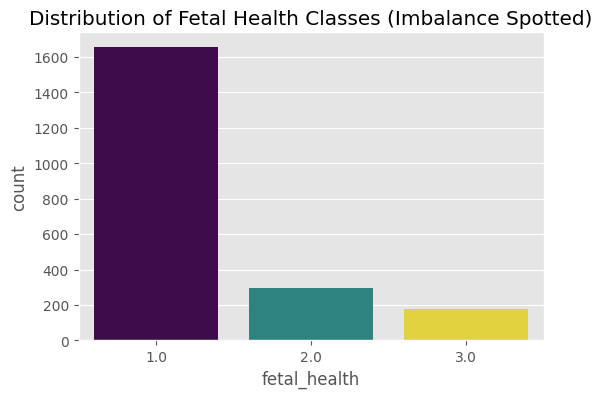

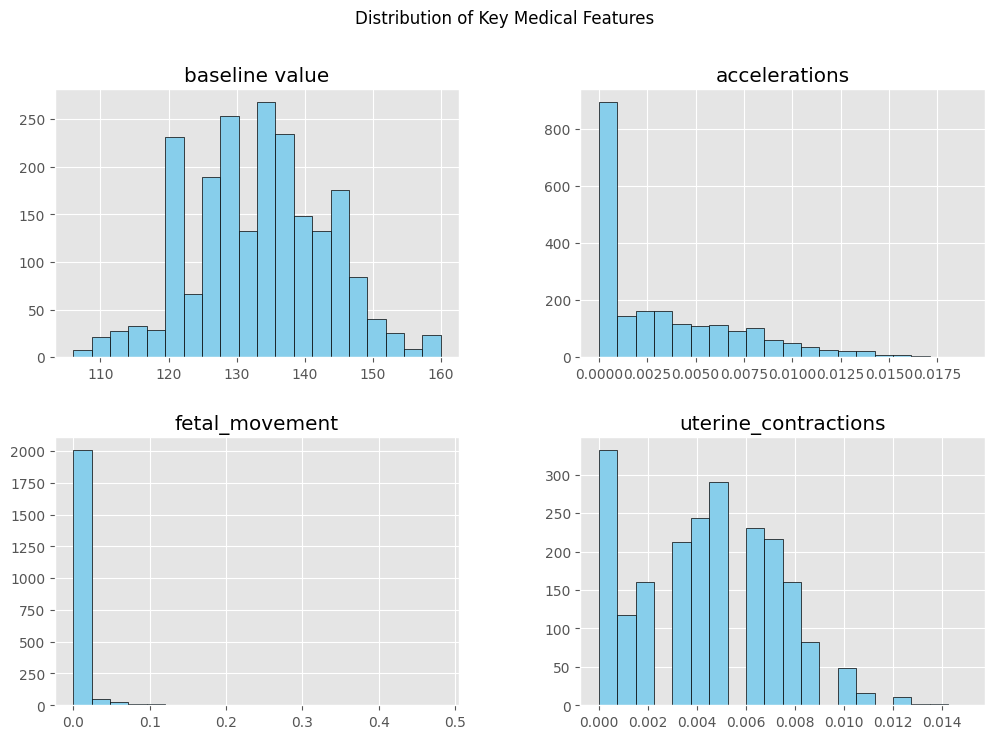

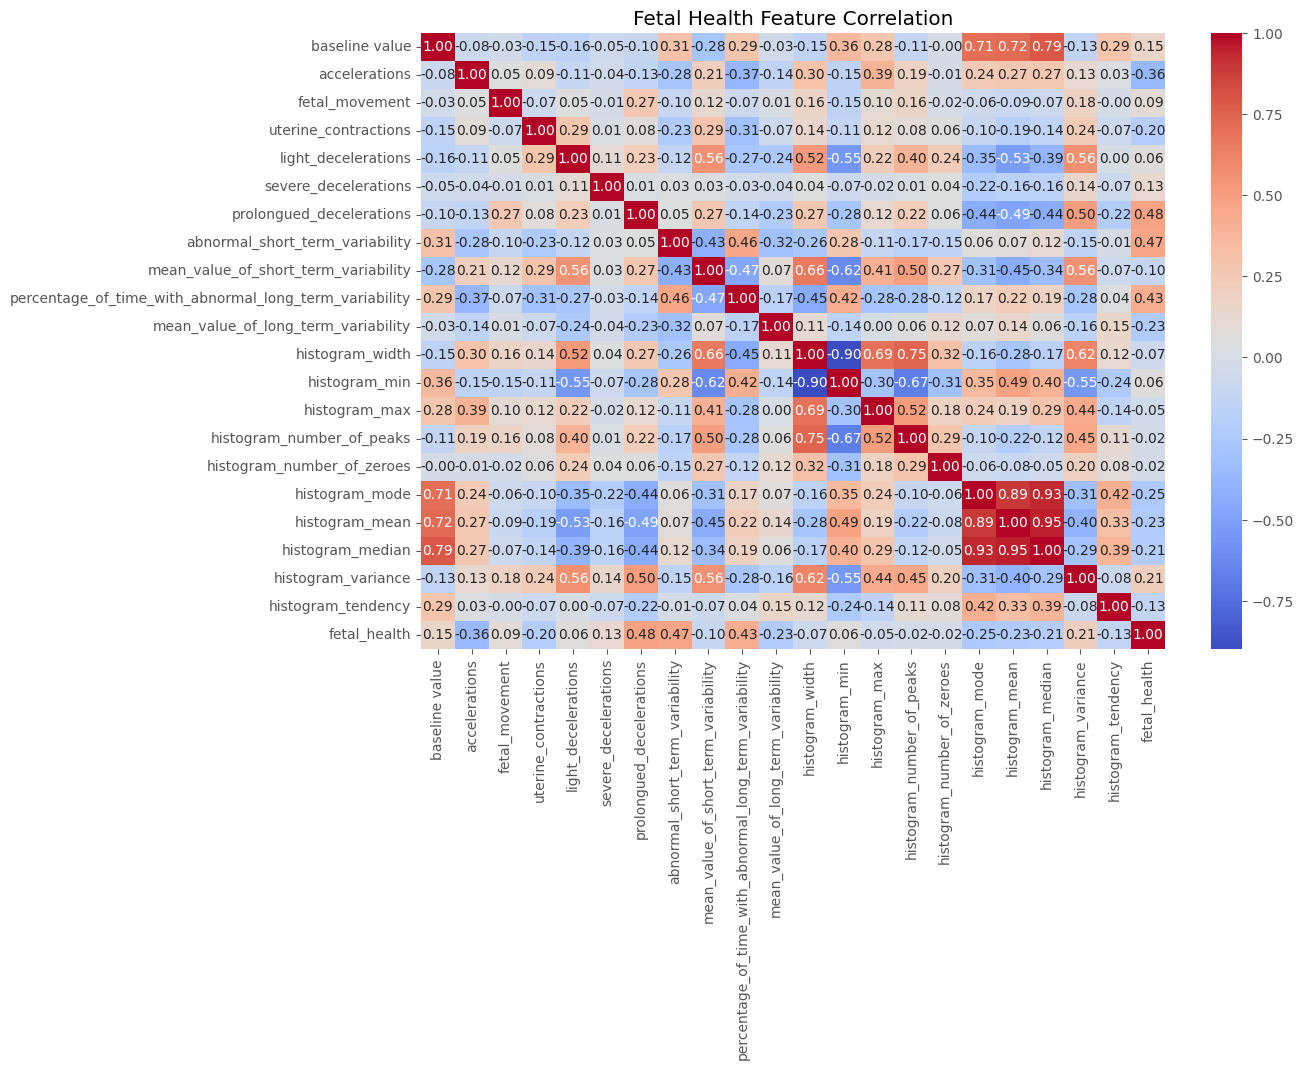

Categorical columns in Fetal Health: []
Index([], dtype='object')


In [74]:
# --- 1. Fetal Health Analysis (Classification) ---

# Summary statistics to understand data distribution
print("Fetal Health Summary Statistics:")
print(df_fetal.shape)
display(df_fetal.head())
print(df_fetal.dtypes)
display(df_fetal.describe())
print("Fetal columns:", df_fetal.columns.tolist())
hist_cols = ['histogram_width', 'histogram_min', 'histogram_max',
             'histogram_mode', 'histogram_mean', 'histogram_median',
             'histogram_variance']
print(df_fetal[hist_cols].corr().round(2))

# Drop highly correlated histogram features

cols_to_drop = ['histogram_mean', 'histogram_median', 'histogram_min']
X_fetal = df_fetal.drop(columns=['fetal_health'] + cols_to_drop)
y_fetal = df_fetal['fetal_health']
scaler_f = StandardScaler()
X_fetal_scaled = pd.DataFrame(scaler_f.fit_transform(X_fetal), columns=X_fetal.columns)
print(f"Remaining features (X): {X_fetal.shape[1]}")
print("Columns in X_fetal:", X_fetal.columns.tolist())
display(X_fetal_scaled.head())

# Checking for missing values (Requirement for Phase One)
print("\nMissing values in Fetal Health:")
print(df_fetal.isnull().sum())

# Class Distribution: Identifying the imbalance issue
plt.figure(figsize=(6,4))
sns.countplot(x='fetal_health', data=df_fetal, palette='viridis', hue='fetal_health', legend=False)
plt.title('Distribution of Fetal Health Classes (Imbalance Spotted)')
plt.show()

# Visualizing distribution of key medical features (Not just target)
important_features = ['baseline value', 'accelerations', 'fetal_movement', 'uterine_contractions']
df_fetal[important_features].hist(bins=20, figsize=(12, 8), color='skyblue', edgecolor='black')
plt.suptitle('Distribution of Key Medical Features')
plt.show()

# Correlation Heatmap to find relationships between features
plt.figure(figsize=(12,8))
sns.heatmap(df_fetal.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Fetal Health Feature Correlation')
plt.show()
# Checking for categorical variables
print("Categorical columns in Fetal Health:", df_fetal.select_dtypes(include=['object']).columns.tolist())
# Checking if there are any date-related columns
print(df_fetal.select_dtypes(include=['datetime64']).columns)

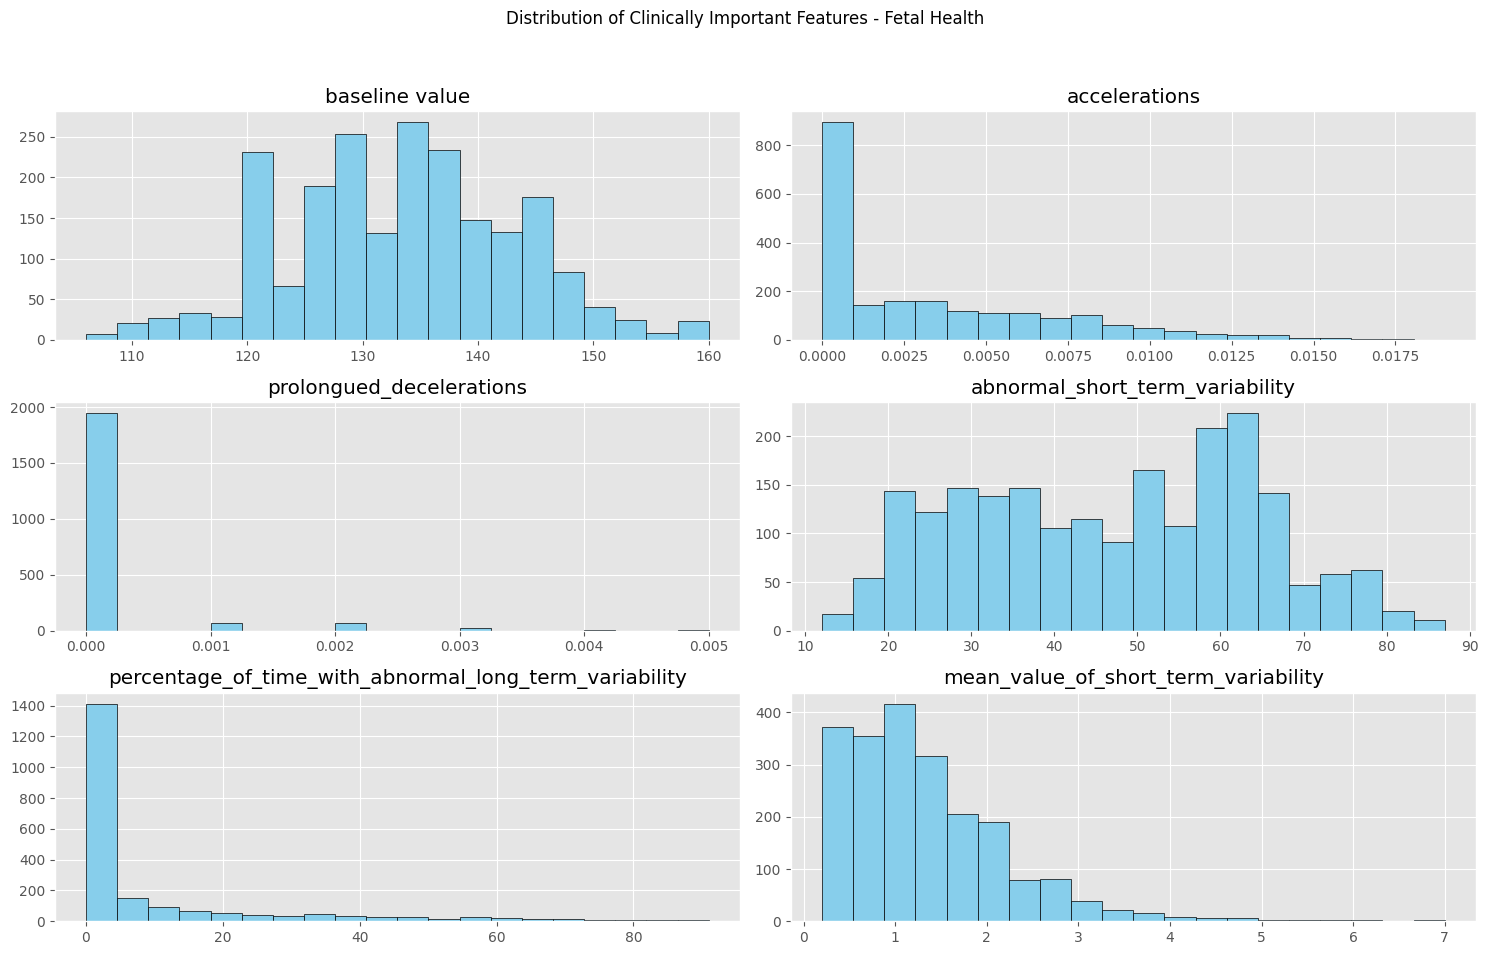

In [66]:

# We chose these specific features as they show high correlation or medical significance
fetal_features_to_plot = [
    'baseline value', 'accelerations', 'prolongued_decelerations',
    'abnormal_short_term_variability', 'percentage_of_time_with_abnormal_long_term_variability',
    'mean_value_of_short_term_variability'
]

df_fetal[fetal_features_to_plot].hist(bins=20, figsize=(15, 10), color='skyblue', edgecolor='black')
plt.suptitle('Distribution of Clinically Important Features - Fetal Health')
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for the title
plt.show()

In [67]:

# Preprocessing: Adjusting target labels and applying Scaling

y_fetal = df_fetal['fetal_health'].astype(int) - 1 # Shift labels to start from 0

print("Fetal Health Preprocessing: Done.")

Fetal Health Preprocessing: Done.


# Phase One Report: Dataset 1 Analysis

## 1. Selected Dataset
* **Name:** Fetal Health Classification
* **Source:** Kaggle

## 2. Task Clarification
* This dataset is selected for the **Classification Task**. The goal is to classify the health of a fetus into three categories: Normal(1), Suspect(2), or Pathological(2).

## 3. Description of Issues & Preprocessing Steps
* **Missing Values:** After checking with `df.isnull().sum()`, no missing values were found. The dataset is clean.
* **Class Imbalance:** After plotting a countplot, I noticed a clear imbalance in the target classes. Most of the samples are "Normal," while "Pathological" cases are much fewer. I need to keep this in mind for the next phase to ensure the model doesn't just bias toward the majority class.
* **Feature Redundancy (Correlation):** By looking at the correlation matrix, I found that some features are telling the same story. For example, histogram_mean, histogram_median, and histogram_mode have a correlation of about 0.95. To keep the model simple and avoid redundant data, I decided to drop the highly correlated columns and keep only the most important ones.
* **Feature Scaling:** The ranges of the features are very different. For instance, baseline value is around 130, while accelerations are very small (less than 0.01). To make sure the model treats all features fairly, I applied StandardScaler to bring everything to the same scale.

* **Label Adjustment:** The original labels were (1, 2, 3). I shifted them to (0, 1, 2) using astype(int) - 1. This is a practical step because most machine learning libraries (like XGBoost) prefer labels to start from zero to avoid technical errors.

I confirmed that all features are numerical, so no categorical encoding was necessary.

Date Parsing: I verified the dataset structure using df.dtypes. Since all features are represented as numerical types (float64) and there are no time-based variables, date parsing is not applicable for this dataset.

# 2. Body Fat Prediction (Regression)

Body Fat Summary Statistics:
(249, 15)


,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
0,1.0708,12.3,23,154.25,67.75,36.2,93.1,85.2,94.5,59.0,37.3,21.9,32.0,27.4,17.1
1,1.0853,6.1,22,173.25,72.25,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2
2,1.0414,25.3,22,154.00,66.25,34.0,95.8,87.9,99.2,59.6,38.9,24.0,28.8,25.2,16.6
3,1.0751,10.4,26,184.75,72.25,37.4,101.8,86.4,101.2,60.1,37.3,22.8,32.4,29.4,18.2
4,1.0340,28.7,24,184.25,71.25,34.4,97.3,100.0,101.9,63.2,42.2,24.0,32.2,27.7,17.7


Density    float64
BodyFat    float64
Age          int64
Weight     float64
Height     float64
Neck       float64
Chest      float64
Abdomen    float64
Hip        float64
Thigh      float64
Knee       float64
Ankle      float64
Biceps     float64
Forearm    float64
Wrist      float64
dtype: object


,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
count,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000
mean,1.055975,18.969478,44.883534,177.743173,70.309237,37.923695,100.551004,92.150602,99.546988,59.196386,38.528514,23.059839,32.200402,28.646185,18.207631
std,0.018788,8.252221,12.677708,26.548892,2.620052,2.270578,7.978692,9.997795,6.241943,4.849462,2.317802,1.638472,2.916216,2.016463,0.893199
min,0.995000,0.000000,22.000000,118.500000,64.000000,31.100000,79.300000,69.400000,85.000000,47.200000,33.000000,19.100000,24.800000,21.000000,15.800000
25%,1.041800,12.400000,35.000000,158.250000,68.250000,36.400000,94.200000,84.500000,95.500000,56.000000,36.900000,22.000000,30.200000,27.300000,17.600000
50%,1.055000,19.200000,43.000000,176.000000,70.000000,38.000000,99.600000,90.900000,99.300000,58.900000,38.400000,22.800000,32.000000,28.700000,18.300000
75%,1.070400,25.200000,54.000000,196.750000,72.250000,39.400000,105.300000,99.100000,103.100000,62.100000,39.900000,24.000000,34.300000,30.000000,18.800000
max,1.108900,47.500000,81.000000,247.250000,77.750000,43.900000,121.600000,122.100000,116.100000,74.400000,46.000000,33.900000,39.100000,34.900000,20.900000



Missing values in Body Fat:
Density    0
BodyFat    0
Age        0
Weight     0
Height     0
Neck       0
Chest      0
Abdomen    0
Hip        0
Thigh      0
Knee       0
Ankle      0
Biceps     0
Forearm    0
Wrist      0
dtype: int64


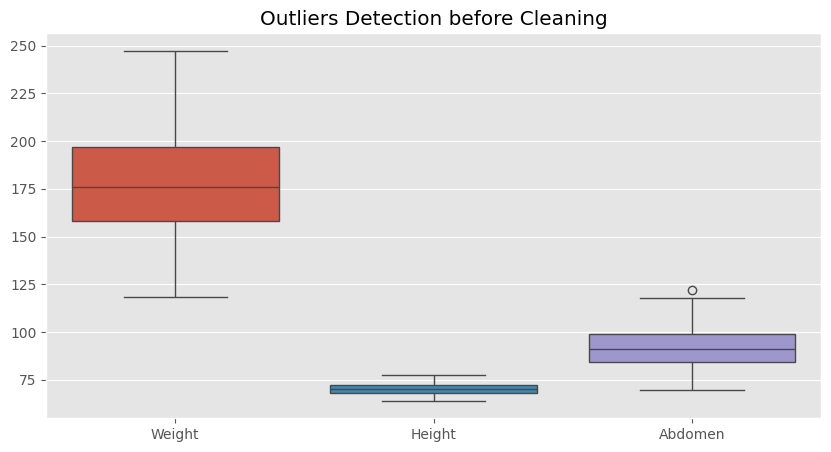

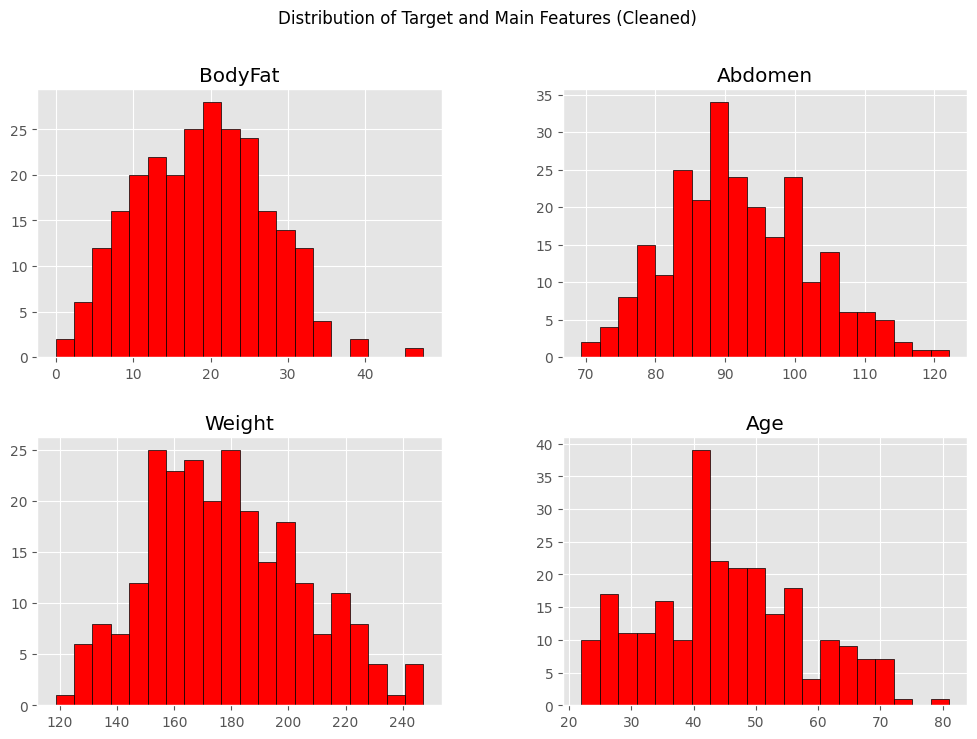

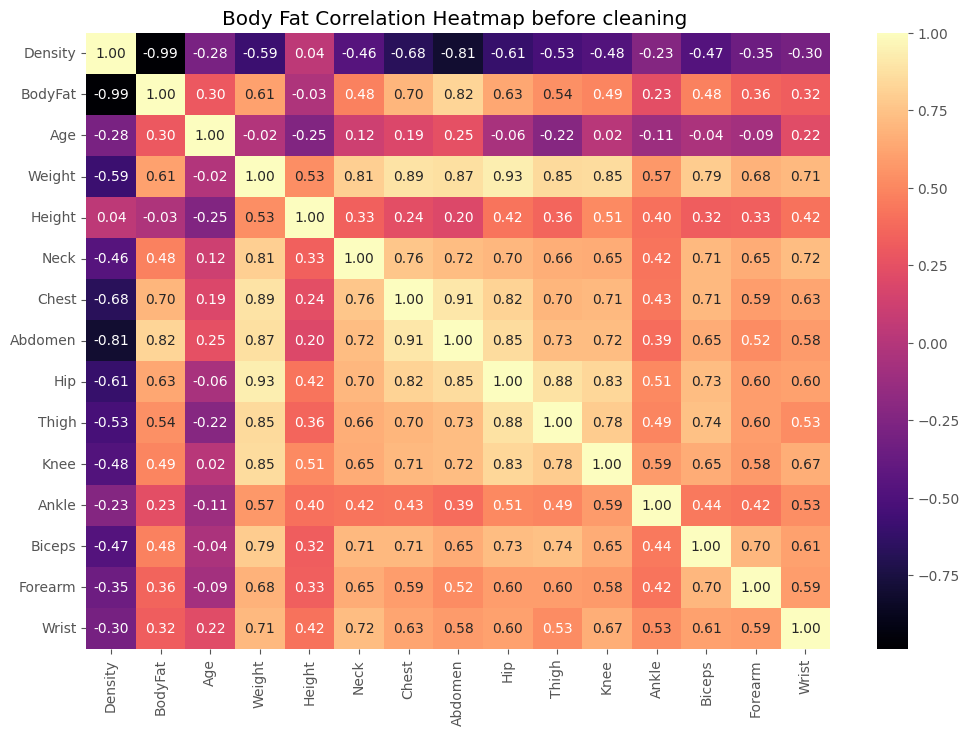

Categorical columns in Body Fat: []
Index([], dtype='object')


In [68]:

# 1. Summary statistics for Body Fat
print("Body Fat Summary Statistics:")
print(df_bodyfat.shape)
display(df_bodyfat.head())
print(df_bodyfat.dtypes)
display(df_bodyfat.describe())

# 2. Check for missing values
print("\nMissing values in Body Fat:")
print(df_bodyfat.isnull().sum())

#3. Detect the Outliers(Boxplot):
plt.figure(figsize=(10,5))
sns.boxplot(data=df_bodyfat[['Weight', 'Height', 'Abdomen']])
plt.title('Outliers Detection before Cleaning')
plt.show()


# 4. Distribution of Body Fat (Target Variable)
features_to_plot = ['BodyFat', 'Abdomen', 'Weight', 'Age']
df_bodyfat[features_to_plot].hist(bins=20, figsize=(12, 8), color='red', edgecolor='black')
plt.suptitle('Distribution of Target and Main Features (Cleaned)')
plt.show()

# 5. Correlation Heatmap for Body Fat
plt.figure(figsize=(12,8))
sns.heatmap(df_bodyfat.corr(), annot=True, cmap='magma', fmt='.2f')
plt.title('Body Fat Correlation Heatmap before cleaning ')
plt.show()
# Checking for categorical variables
print("Categorical columns in Body Fat:", df_bodyfat.select_dtypes(include=['object']).columns.tolist())
# Checking if there are any date-related columns
print(df_bodyfat.select_dtypes(include=['datetime64']).columns)

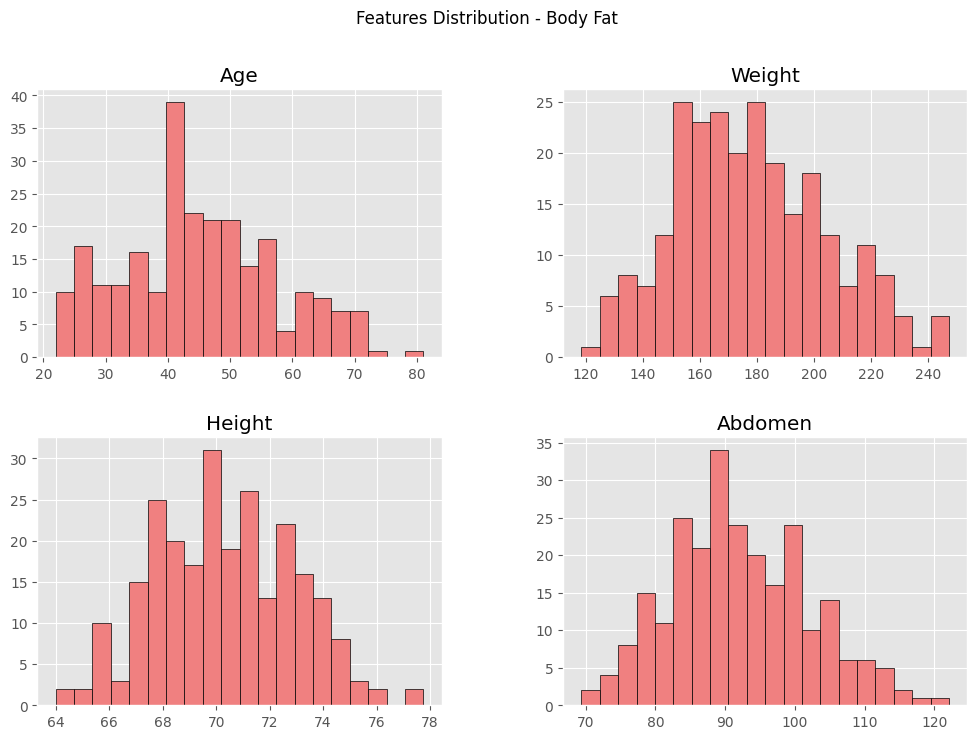

In [69]:

# looking at the distribution of body measurements
body_cols = ['Age', 'Weight', 'Height', 'Abdomen']
df_bodyfat[body_cols].hist(bins=20, figsize=(12, 8), color='lightcoral', edgecolor='black')
plt.suptitle('Features Distribution - Body Fat')
plt.show()

Outliers handled. New dataset shape: (249, 15)
Scaling applied. Shape: (249, 13)
Data is ready for Phase Two.


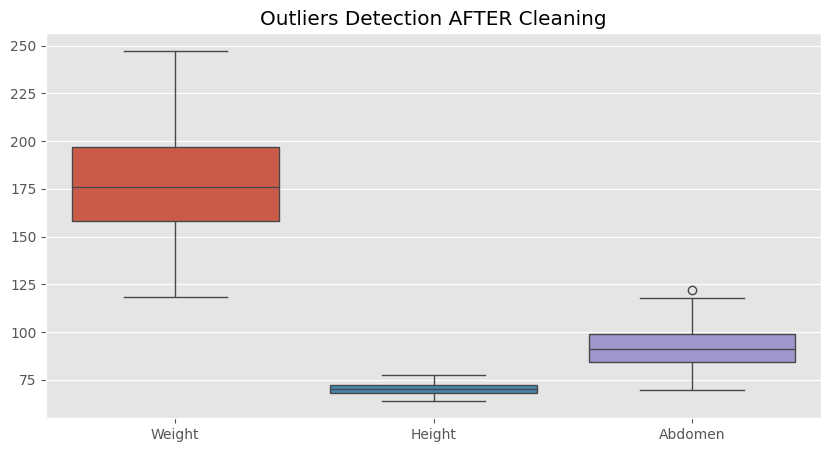

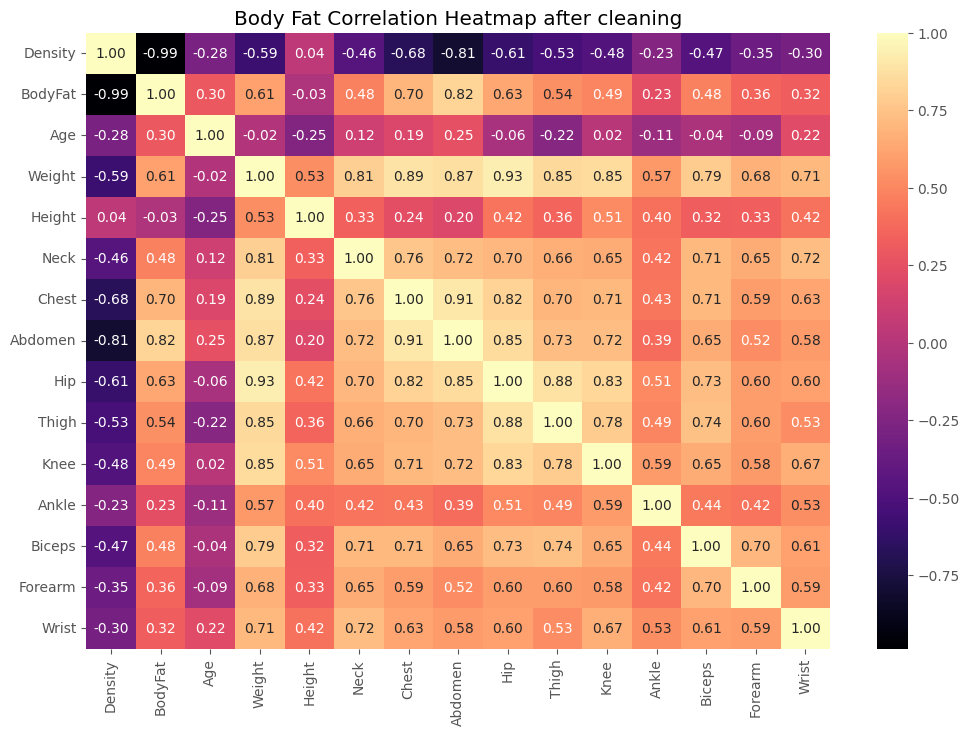

In [70]:

# preparing the data for the next phase

# --- Handling Outliers for Body Fat Dataset ---

# 1. Handling Height manually (because 29.5 is a logical error, not just a statistical outlier)
df_bodyfat = df_bodyfat[df_bodyfat['Height'] > 40]

# 2. Handling Weight using IQR Method
Q1_w = df_bodyfat['Weight'].quantile(0.25)
Q3_w = df_bodyfat['Weight'].quantile(0.75)
IQR_w = Q3_w - Q1_w
lower_w = Q1_w - 1.5 * IQR_w
upper_w = Q3_w + 1.5 * IQR_w

df_bodyfat = df_bodyfat[(df_bodyfat['Weight'] >= lower_w) & (df_bodyfat['Weight'] <= upper_w)]
print(f"Outliers handled. New dataset shape: {df_bodyfat.shape}")
# for body fat: removing Density because it is highly related to BodyFat


X_bodyfat = df_bodyfat.drop(['BodyFat', 'Density'], axis=1)
y_bodyfat = df_bodyfat['BodyFat']
scaler_b = StandardScaler()
X_bodyfat_scaled = pd.DataFrame(scaler_b.fit_transform(X_bodyfat), columns=X_bodyfat.columns)
print(f"Scaling applied. Shape: {X_bodyfat_scaled.shape}")

print("Data is ready for Phase Two.")
# Boxplot after cleaning
plt.figure(figsize=(10,5))
sns.boxplot(data=df_bodyfat[['Weight', 'Height', 'Abdomen']])
plt.title('Outliers Detection AFTER Cleaning')
plt.show()
#Heatmap after cleaning
plt.figure(figsize=(12,8))
sns.heatmap(df_bodyfat.corr(), annot=True, cmap='magma', fmt='.2f')
plt.title('Body Fat Correlation Heatmap after cleaning')
plt.show()

Phase One Report: Dataset 2 Analysis
1. Selected Dataset
Name: Body Fat Prediction Dataset.

Task: Regression (Predicting a continuous percentage value).

2. Exploratory Data Analysis (EDA) Observations
Target Distribution: The Histogram shows that the BodyFat percentage follows a roughly normal distribution, centered around 19%.

High Correlation: The heatmap shows that Abdomen size has a very strong relationship with Body Fat (0.81), so it's a very important feature.

Data Integrity: No missing values were found.

3. Identified Issues & Outliers
Anomalous Outliers: In the summary statistics (describe), the minimum Height is 29.5 inches, which is unrealistic for an adult and indicates an outlier/entry error.

Extreme Weights: The maximum weight is 363.15 lbs, which is significantly higher than the average.

**Preprocessing & Handling:** I addressed these outliers in this phase to ensure a clean dataset for the regression model. Specifically, I manually filtered out the unrealistic height (29.5 inches) and used the IQR method to handle extreme weight values. This cleaning step significantly improved the data distribution for Phase Two."

Checked for categorical variables and found none; therefore, all features were processed as numerical data.

Date Parsing: I verified the dataset structure using df.dtypes. Since all features are represented as numerical types (int64/float64) and there are no time-based variables, date parsing is not applicable for this dataset.